# EDA — CMU-MOSEI: Emotion Recognition (ER)

Разведочный анализ данных для задачи распознавания эмоций.  
**Датасет:** CMU-MOSEI (train / validation / test splits, текстовая модальность).  
**Задача в модели:** многоклассовая классификация (dominant-label CE) + SSL в fusion-стадии.

---
Разделы:
1. Загрузка данных и базовая статистика  
2. Распределение доминирующего класса (дисбаланс)  
3. Интенсивность эмоциональных оценок  
4. Multi-label анализ  
5. Матрица совстречаемости эмоций  
6. Корреляция эмоций  
7. Анализ sentiment-оценки  
8. Длина текстов  
9. Консистентность сплитов  
10. Дубликаты и аномалии  
11. Примеры по классам  
12. Выводы для НИРа

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("mosei_data")

train = pd.read_csv(DATA_DIR / "train.csv")
val   = pd.read_csv(DATA_DIR / "validation.csv")
test  = pd.read_csv(DATA_DIR / "test.csv")

EMO_COLS = ["Happiness", "Sadness", "Anger", "Surprise", "Disgust", "Fear", "Neutral"]
EMO_PALETTE = {
    "Happiness": "#f4c542",
    "Sadness":   "#5b9bd5",
    "Anger":     "#e05252",
    "Surprise":  "#a67cbf",
    "Disgust":   "#6abf69",
    "Fear":      "#f4a042",
    "Neutral":   "#9e9e9e",
}

print("Загружено сплитов:")
for name, df in [("train", train), ("val", val), ("test", test)]:
    print(f"  {name:5s}: {df.shape[0]:>5} строк, {df.shape[1]} колонок")

print("\nКолонки:", train.columns.tolist())

Загружено сплитов:
  train: 16274 строк, 13 колонок
  val  :  4653 строк, 13 колонок
  test :  1861 строк, 13 колонок

Колонки: ['video', 'start_time', 'end_time', 'sentiment', 'Happiness', 'Sadness', 'Anger', 'Surprise', 'Disgust', 'Fear', 'text', 'ASR', 'Neutral']


## 1. Базовая статистика

In [2]:
print("=== Типы данных ===")
print(train.dtypes)
print()
print("=== Пропуски (train) ===")
print(train.isnull().sum())
print()
print("=== Описательная статистика эмоциональных оценок (train) ===")
train[EMO_COLS].describe().round(4)

=== Типы данных ===
video          object
start_time    float64
end_time      float64
sentiment     float64
Happiness     float64
Sadness       float64
Anger         float64
Surprise      float64
Disgust       float64
Fear          float64
text           object
ASR            object
Neutral       float64
dtype: object

=== Пропуски (train) ===
video         0
start_time    0
end_time      0
sentiment     0
Happiness     0
Sadness       0
Anger         0
Surprise      0
Disgust       0
Fear          0
text          0
ASR           0
Neutral       0
dtype: int64

=== Описательная статистика эмоциональных оценок (train) ===


,Happiness,Sadness,Anger,Surprise,Disgust,Fear,Neutral
count,16274.0000,16274.0000,16274.0000,16274.0000,16274.0000,16274.0000,16274.0000
mean,0.4868,0.1613,0.1582,0.0489,0.1247,0.0405,0.1462
std,0.6401,0.3315,0.3678,0.1722,0.3276,0.1519,0.3533
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.3333,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
75%,0.6667,0.3333,0.0000,0.0000,0.0000,0.0000,0.0000
max,3.0000,3.0000,3.0000,3.0000,3.0000,1.6667,1.0000


In [3]:
# Уникальные видео и клипы
print(f"Уникальных видео  (train): {train['video'].nunique()}")
print(f"Клипов на видео   (train): mean={train.groupby('video').size().mean():.1f}, "
      f"median={train.groupby('video').size().median():.0f}, max={train.groupby('video').size().max()}")
print()
# Диапазоны времени
train["duration"] = train["end_time"] - train["start_time"]
print(f"Длительность клипа (сек): mean={train['duration'].mean():.2f}, "
      f"median={train['duration'].median():.2f}, max={train['duration'].max():.2f}")

Уникальных видео  (train): 2244
Клипов на видео   (train): mean=7.3, median=5, max=98

Длительность клипа (сек): mean=7.16, median=6.02, max=108.93


## 2. Распределение доминирующего класса (дисбаланс)

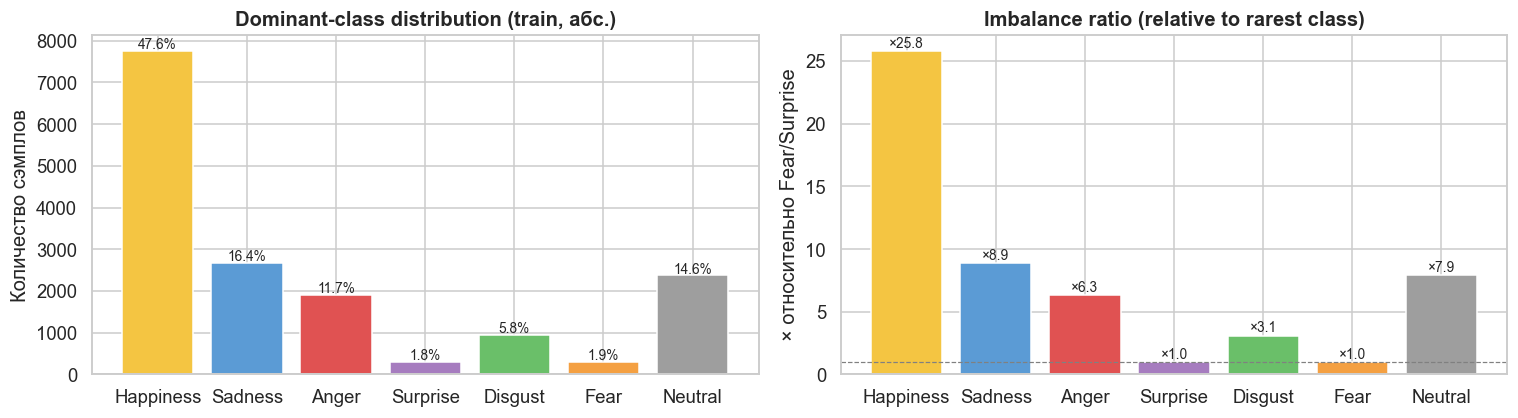


Rarest class: Surprise (301 сэмплов)
Most frequent: Happiness (7753 сэмплов)
Max imbalance ratio: 25.8×


In [4]:
for df in [train, val, test]:
    df["dominant"] = df[EMO_COLS].idxmax(axis=1)

dom_counts = train["dominant"].value_counts().reindex(EMO_COLS)
dom_pct    = (dom_counts / dom_counts.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Абсолютные числа
colors = [EMO_PALETTE[e] for e in dom_counts.index]
axes[0].bar(dom_counts.index, dom_counts.values, color=colors, edgecolor="white")
axes[0].set_title("Dominant-class distribution (train, абс.)", fontweight="bold")
axes[0].set_ylabel("Количество сэмплов")
for i, (v, p) in enumerate(zip(dom_counts.values, dom_pct.values)):
    axes[0].text(i, v + 50, f"{p}%", ha="center", fontsize=9)

# Дисбаланс относительно наименее представленного класса
min_cls = dom_counts.min()
imbalance = (dom_counts / min_cls).round(1)
axes[1].bar(imbalance.index, imbalance.values, color=colors, edgecolor="white")
axes[1].set_title("Imbalance ratio (relative to rarest class)", fontweight="bold")
axes[1].set_ylabel("× относительно Fear/Surprise")
axes[1].axhline(1, color="gray", linestyle="--", linewidth=0.8)
for i, v in enumerate(imbalance.values):
    axes[1].text(i, v + 0.3, f"×{v}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nRarest class: {dom_counts.idxmin()} ({dom_counts.min()} сэмплов)")
print(f"Most frequent: {dom_counts.idxmax()} ({dom_counts.max()} сэмплов)")
print(f"Max imbalance ratio: {imbalance.max():.1f}×")

## 3. Интенсивность эмоциональных оценок

Оценки — дробные числа (среднее по аннотаторам, кратные 1/6). Диапазон 0–3.

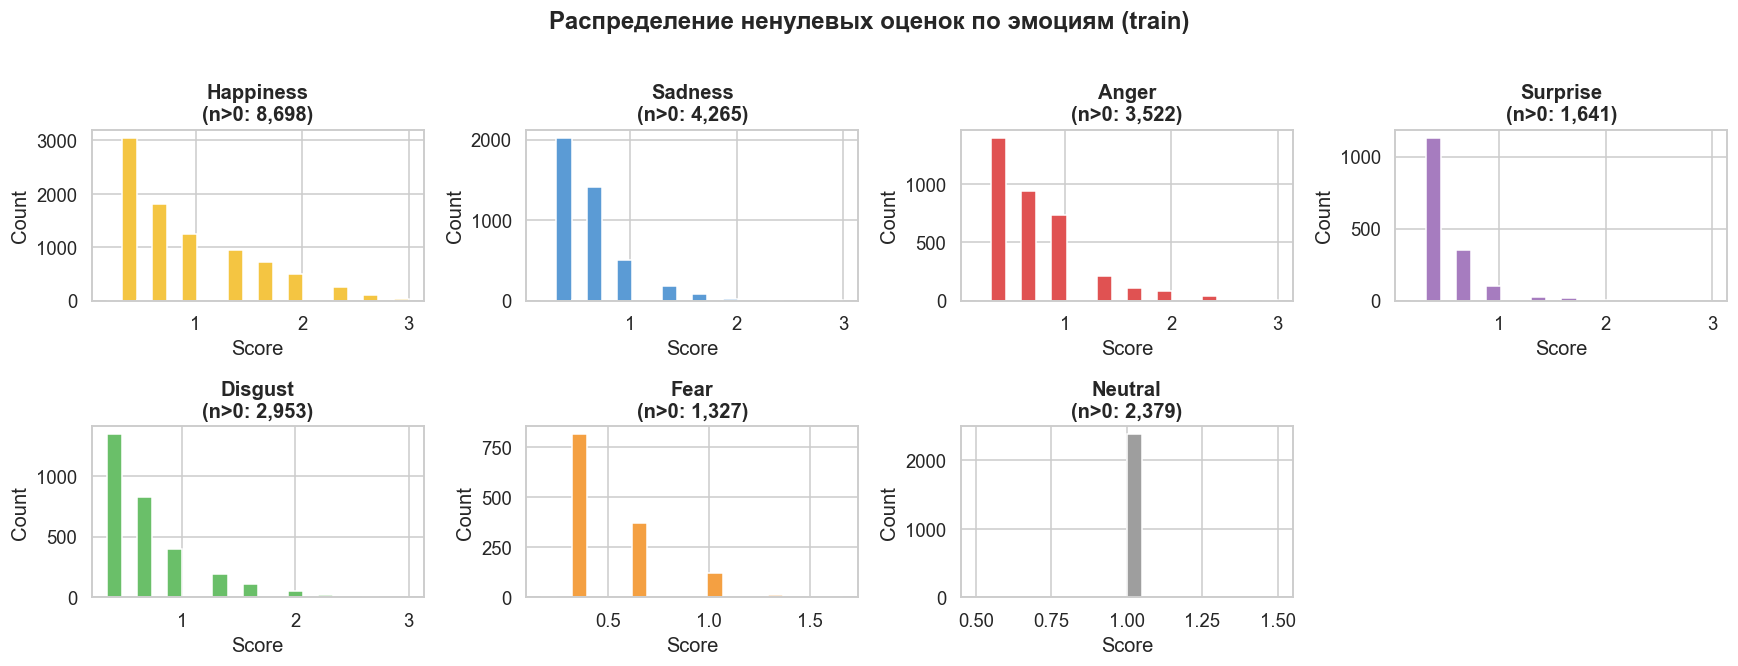

Доля нулевых оценок (emo=0) по классам:
  Happiness   : 46.6% нулей
  Sadness     : 73.8% нулей
  Anger       : 78.4% нулей
  Surprise    : 89.9% нулей
  Disgust     : 81.9% нулей
  Fear        : 91.8% нулей
  Neutral     : 85.4% нулей


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey=False)
axes = axes.flatten()

for i, emo in enumerate(EMO_COLS):
    nonzero = train[train[emo] > 0][emo]
    axes[i].hist(nonzero, bins=20, color=EMO_PALETTE[emo], edgecolor="white")
    axes[i].set_title(f"{emo}\n(n>0: {len(nonzero):,})", fontweight="bold")
    axes[i].set_xlabel("Score")
    axes[i].set_ylabel("Count")

axes[-1].axis("off")  # 8-я ячейка пустая
plt.suptitle("Распределение ненулевых оценок по эмоциям (train)", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Процент нулевых оценок
print("Доля нулевых оценок (emo=0) по классам:")
for emo in EMO_COLS:
    zero_pct = (train[emo] == 0).mean() * 100
    print(f"  {emo:<12}: {zero_pct:.1f}% нулей")

/var/folders/pn/8q4knbjn5rj60_0r74hvf_dw0000gn/T/ipykernel_16527/179232983.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=EMO_COLS, patch_artist=True, notch=False,


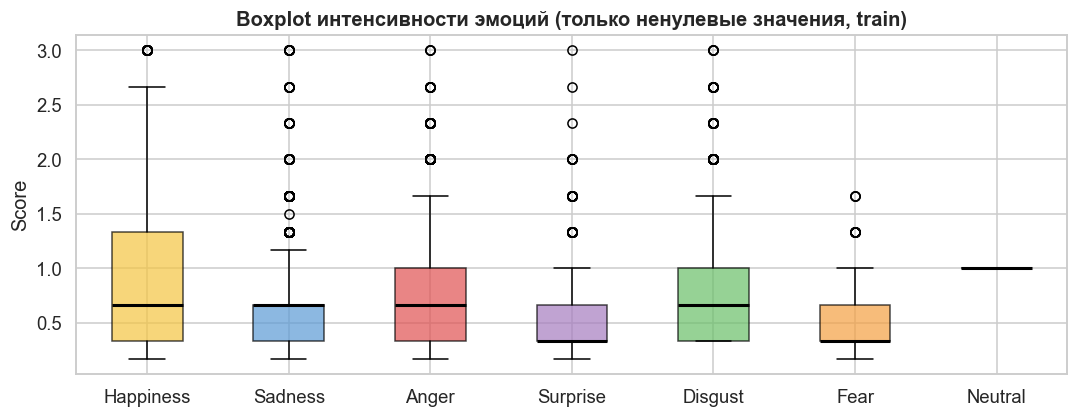

In [6]:
# Mean score по каждой эмоции + boxplot
fig, ax = plt.subplots(figsize=(10, 4))
data_to_plot = [train[train[e] > 0][e].values for e in EMO_COLS]
bp = ax.boxplot(data_to_plot, labels=EMO_COLS, patch_artist=True, notch=False,
                medianprops=dict(color="black", linewidth=2))
for patch, emo in zip(bp["boxes"], EMO_COLS):
    patch.set_facecolor(EMO_PALETTE[emo])
    patch.set_alpha(0.7)
ax.set_title("Boxplot интенсивности эмоций (только ненулевые значения, train)", fontweight="bold")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

## 4. Multi-label анализ

Один сэмпл может содержать несколько ненулевых эмоций одновременно.

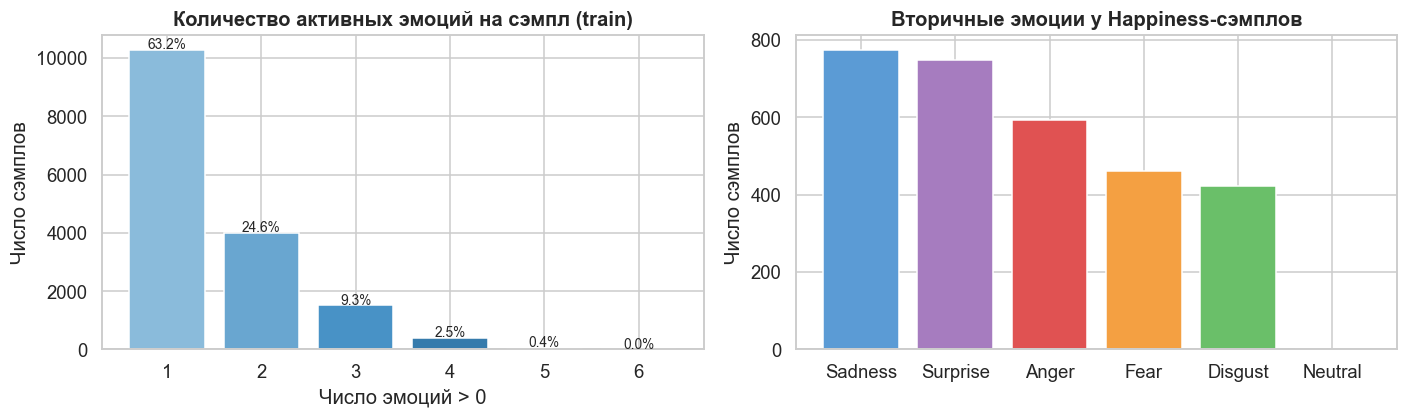

Multi-label покрытие:
       count   pct
n_emo             
1      10285  63.2
2       4004  24.6
3       1519   9.3
4        401   2.5
5         59   0.4
6          6   0.0


In [7]:
train["n_emo"] = (train[EMO_COLS] > 0).sum(axis=1)
n_emo_counts = train["n_emo"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Количество эмоций на сэмпл
axes[0].bar(n_emo_counts.index, n_emo_counts.values,
            color=sns.color_palette("Blues_d", len(n_emo_counts)), edgecolor="white")
axes[0].set_title("Количество активных эмоций на сэмпл (train)", fontweight="bold")
axes[0].set_xlabel("Число эмоций > 0")
axes[0].set_ylabel("Число сэмплов")
for x, v in zip(n_emo_counts.index, n_emo_counts.values):
    axes[0].text(x, v + 30, f"{v/len(train)*100:.1f}%", ha="center", fontsize=9)

# Dominant vs secondary: что идёт "вторым" для Happiness
hap_mask  = train["dominant"] == "Happiness"
secondary = (train.loc[hap_mask, [e for e in EMO_COLS if e != "Happiness"]] > 0).sum()
secondary_sorted = secondary.sort_values(ascending=False)
axes[1].bar(secondary_sorted.index, secondary_sorted.values,
            color=[EMO_PALETTE[e] for e in secondary_sorted.index], edgecolor="white")
axes[1].set_title("Вторичные эмоции у Happiness-сэмплов", fontweight="bold")
axes[1].set_ylabel("Число сэмплов")

plt.tight_layout()
plt.show()

print("Multi-label покрытие:")
print(n_emo_counts.to_frame("count").assign(pct=lambda d: (d["count"]/len(train)*100).round(1)))

## 5. Матрица совстречаемости эмоций

Насколько часто две эмоции присутствуют в одном сэмпле одновременно (оба > 0).

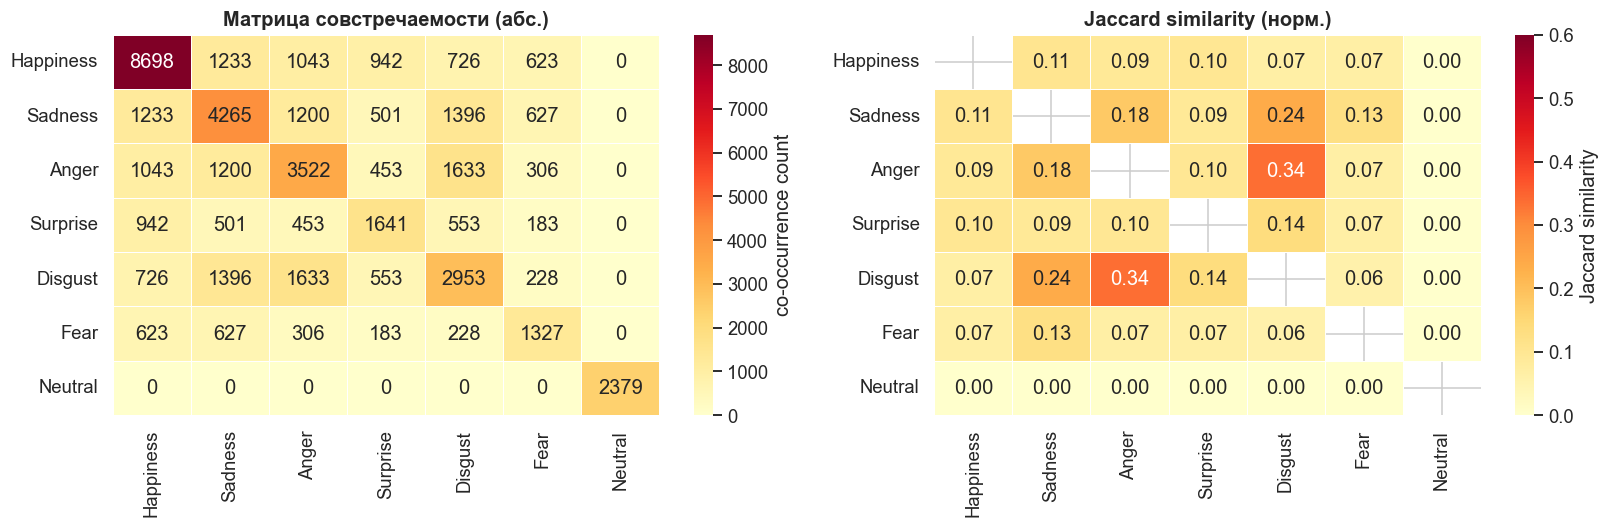

Neutral совместно с другими эмоциями: 0


In [8]:
binary = (train[EMO_COLS] > 0).astype(int)
cooc   = binary.T.dot(binary)

# Нормализованная (Jaccard-like: co-occur / union)
cooc_norm = pd.DataFrame(index=EMO_COLS, columns=EMO_COLS, dtype=float)
for a in EMO_COLS:
    for b in EMO_COLS:
        both  = ((binary[a] == 1) & (binary[b] == 1)).sum()
        union = ((binary[a] == 1) | (binary[b] == 1)).sum()
        cooc_norm.loc[a, b] = both / union if union > 0 else 0.0

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(cooc, annot=True, fmt="d", cmap="YlOrRd", ax=axes[0],
            linewidths=0.5, linecolor="white", cbar_kws={"label": "co-occurrence count"})
axes[0].set_title("Матрица совстречаемости (абс.)", fontweight="bold")

mask = np.eye(len(EMO_COLS), dtype=bool)
sns.heatmap(cooc_norm.astype(float), annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[1],
            mask=mask, linewidths=0.5, linecolor="white", vmin=0, vmax=0.6,
            cbar_kws={"label": "Jaccard similarity"})
axes[1].set_title("Jaccard similarity (норм.)", fontweight="bold")

plt.tight_layout()
plt.show()

# Нейтральность — особый случай: не совстречается ни с чем
print("Neutral совместно с другими эмоциями:", int(cooc.loc["Neutral", [e for e in EMO_COLS if e != "Neutral"]].sum()))

## 6. Корреляция эмоциональных оценок (Pearson)

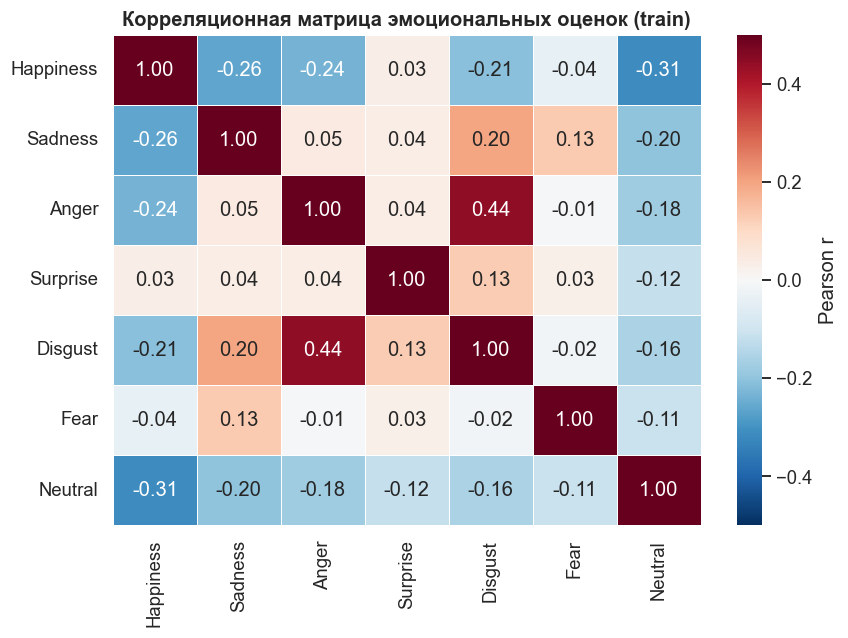


Наиболее скоррелированные пары:
Disgust    Anger        0.442
Anger      Disgust      0.442
Neutral    Happiness   -0.315
Happiness  Neutral     -0.315
           Sadness     -0.262
Sadness    Happiness   -0.262
Anger      Happiness   -0.237
Happiness  Anger       -0.237
Disgust    Happiness   -0.209
Happiness  Disgust     -0.209
dtype: float64


In [9]:
corr = train[EMO_COLS].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=ax, linewidths=0.5, linecolor="white", vmin=-0.5, vmax=0.5,
            cbar_kws={"label": "Pearson r"})
ax.set_title("Корреляционная матрица эмоциональных оценок (train)", fontweight="bold")
plt.tight_layout()
plt.show()

print("\nНаиболее скоррелированные пары:")
corr_flat = corr.where(~np.eye(len(EMO_COLS), dtype=bool)).stack().sort_values(key=abs, ascending=False)
print(corr_flat.head(10).round(3))

## 7. Анализ sentiment-оценки

`sentiment` ∈ [–3, 3] — общая валентность высказывания.

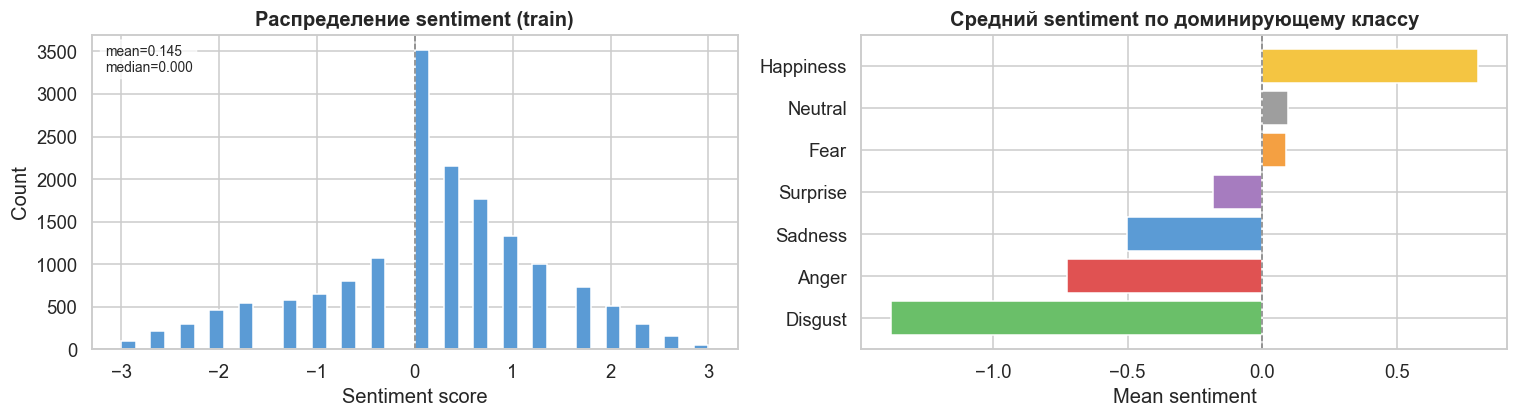

            mean    std    min    max
dominant                             
Anger     -0.725  1.115 -3.000  2.667
Disgust   -1.379  0.895 -3.000  2.333
Fear       0.088  0.680 -2.333  2.333
Happiness  0.801  0.865 -3.000  3.000
Neutral    0.094  0.549 -2.333  2.667
Sadness   -0.504  0.961 -3.000  2.667
Surprise  -0.183  0.862 -3.000  2.667


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Распределение sentiment
axes[0].hist(train["sentiment"], bins=40, color="#5b9bd5", edgecolor="white")
axes[0].axvline(0, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Распределение sentiment (train)", fontweight="bold")
axes[0].set_xlabel("Sentiment score")
axes[0].set_ylabel("Count")
axes[0].text(0.02, 0.97,
             f"mean={train['sentiment'].mean():.3f}\nmedian={train['sentiment'].median():.3f}",
             transform=axes[0].transAxes, va="top", fontsize=9,
             bbox=dict(boxstyle="round", fc="white", alpha=0.7))

# Sentiment по доминирующему классу
order = train.groupby("dominant")["sentiment"].mean().sort_values().index
palette = [EMO_PALETTE[e] for e in order]
axes[1].barh(order, train.groupby("dominant")["sentiment"].mean().reindex(order),
             color=palette, edgecolor="white")
axes[1].axvline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Средний sentiment по доминирующему классу", fontweight="bold")
axes[1].set_xlabel("Mean sentiment")

plt.tight_layout()
plt.show()

# Таблица
sent_stats = train.groupby("dominant")["sentiment"].agg(["mean", "std", "min", "max"]).round(3)
print(sent_stats)

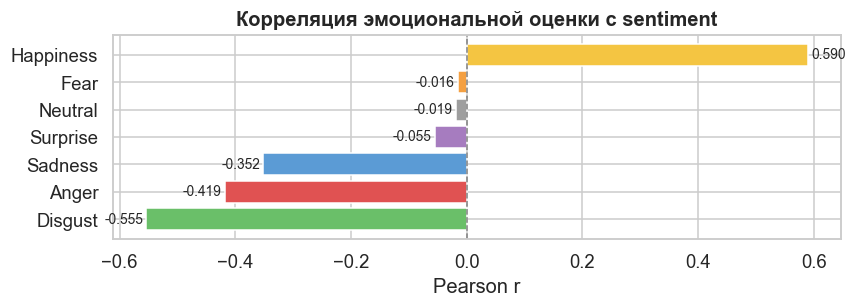

In [11]:
# Корреляция sentiment с каждой эмоцией
sent_corr = train[EMO_COLS].corrwith(train["sentiment"]).sort_values()

fig, ax = plt.subplots(figsize=(8, 3))
colors = [EMO_PALETTE[e] for e in sent_corr.index]
ax.barh(sent_corr.index, sent_corr.values, color=colors, edgecolor="white")
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_title("Корреляция эмоциональной оценки с sentiment", fontweight="bold")
ax.set_xlabel("Pearson r")
for i, v in enumerate(sent_corr.values):
    ax.text(v + (0.005 if v >= 0 else -0.005), i, f"{v:.3f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=9)
plt.tight_layout()
plt.show()

## 8. Длина текстов

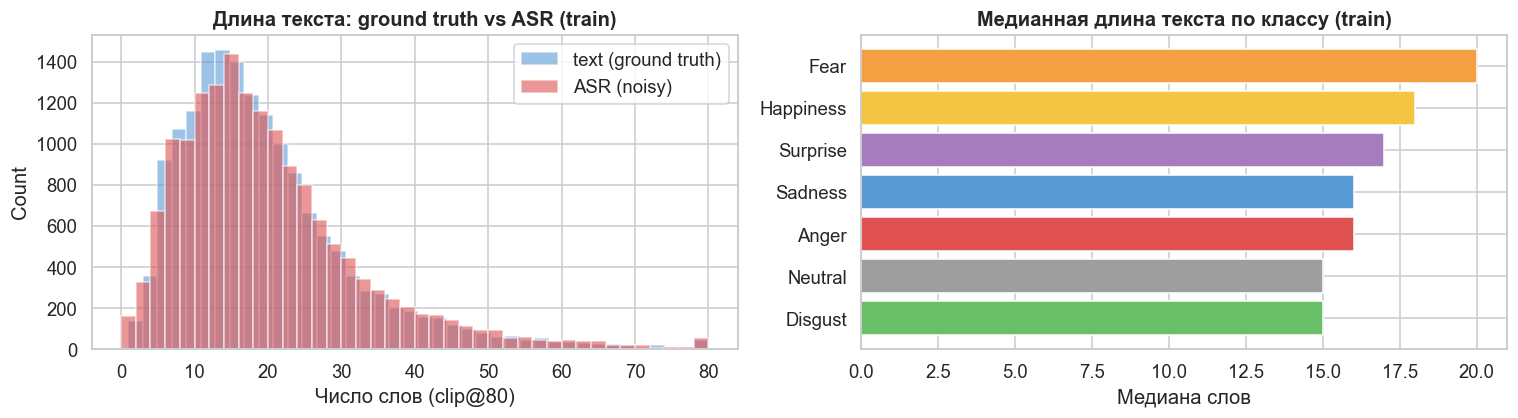

text_len: mean=19.6, median=17, p95=44, max=307
Сэмплов с text_len > 50 слов: 481 (3.0%)

Prime BGE-small input limit: 512 tokens ≈ ~390 words → все тексты влезают ✓


In [12]:
train["text_len"]  = train["text"].str.split().str.len()
train["asr_len"]   = train["ASR"].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram text vs ASR
axes[0].hist(train["text_len"].clip(upper=80), bins=40,
             alpha=0.6, label="text (ground truth)", color="#5b9bd5", edgecolor="white")
axes[0].hist(train["asr_len"].clip(upper=80), bins=40,
             alpha=0.6, label="ASR (noisy)", color="#e05252", edgecolor="white")
axes[0].set_title("Длина текста: ground truth vs ASR (train)", fontweight="bold")
axes[0].set_xlabel("Число слов (clip@80)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Длина по доминирующему классу
len_by_cls = train.groupby("dominant")["text_len"].median().sort_values()
axes[1].barh(len_by_cls.index, len_by_cls.values,
             color=[EMO_PALETTE[e] for e in len_by_cls.index], edgecolor="white")
axes[1].set_title("Медианная длина текста по классу (train)", fontweight="bold")
axes[1].set_xlabel("Медиана слов")

plt.tight_layout()
plt.show()

print(f"text_len: mean={train['text_len'].mean():.1f}, median={train['text_len'].median():.0f}, "
      f"p95={train['text_len'].quantile(0.95):.0f}, max={train['text_len'].max()}")
print(f"Сэмплов с text_len > 50 слов: {(train['text_len'] > 50).sum()} ({(train['text_len'] > 50).mean()*100:.1f}%)")

# BGE-small принимает до 512 токенов; при ~1.3 токен/слово 50 слов = ~65 токенов — всё влезает
print(f"\nPrime BGE-small input limit: 512 tokens ≈ ~390 words → все тексты влезают ✓")

## 9. Консистентность сплитов (train / val / test)

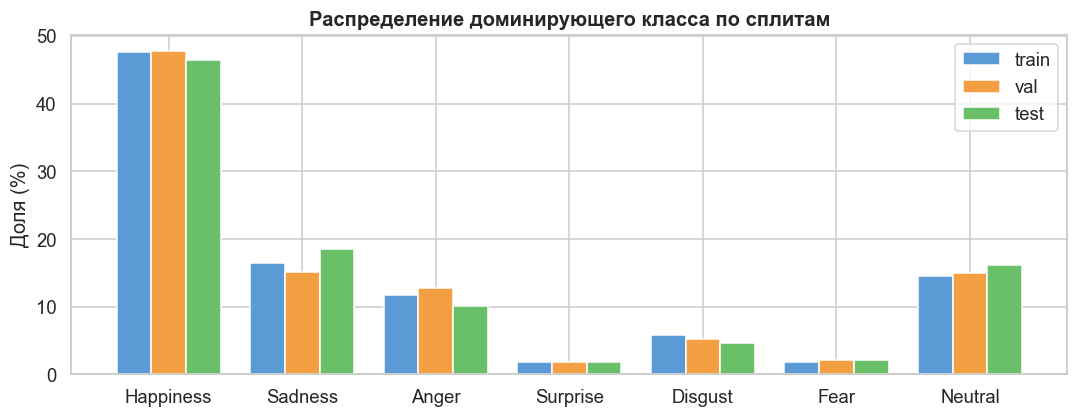

           train   val  test
dominant                    
Happiness   47.6  47.8  46.4
Sadness     16.4  15.1  18.6
Anger       11.7  12.8  10.1
Surprise     1.8   1.9   1.9
Disgust      5.8   5.3   4.7
Fear         1.9   2.1   2.1
Neutral     14.6  15.0  16.1


In [13]:
splits = {"train": train, "val": val, "test": test}
for df in splits.values():
    df["dominant"] = df[EMO_COLS].idxmax(axis=1)

dist_df = pd.DataFrame({
    name: df["dominant"].value_counts(normalize=True).reindex(EMO_COLS, fill_value=0) * 100
    for name, df in splits.items()
}).round(1)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(EMO_COLS))
width = 0.26
colors_split = ["#5b9bd5", "#f4a042", "#6abf69"]
for i, (col, c) in enumerate(zip(dist_df.columns, colors_split)):
    ax.bar(x + i * width, dist_df[col], width, label=col, color=c, edgecolor="white")
ax.set_xticks(x + width)
ax.set_xticklabels(EMO_COLS)
ax.set_ylabel("Доля (%)")
ax.set_title("Распределение доминирующего класса по сплитам", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(dist_df)

In [14]:
# Утечка видео между сплитами?
train_videos = set(train["video"])
val_videos   = set(val["video"])
test_videos  = set(test["video"])

print(f"Уникальных видео: train={len(train_videos)}, val={len(val_videos)}, test={len(test_videos)}")
print(f"Пересечение train∩val:  {len(train_videos & val_videos)} видео")
print(f"Пересечение train∩test: {len(train_videos & test_videos)} видео")
print(f"Пересечение val∩test:   {len(val_videos & test_videos)} видео")

Уникальных видео: train=2244, val=675, test=298
Пересечение train∩val:  0 видео
Пересечение train∩test: 0 видео
Пересечение val∩test:   0 видео


## 10. Дубликаты и аномалии

In [15]:
dup_texts = train[train["text"].duplicated(keep=False)].sort_values("text")
print(f"Дублирующихся текстов (train): {train['text'].duplicated().sum()}")
print(f"Уникальных дублирующихся строк: {train['text'].duplicated(keep=False).sum()}")

# Пример дубликатов с разными метками
dup_ex = dup_texts.groupby("text").filter(lambda g: g["dominant"].nunique() > 1)
print(f"\nДубликатов с разными доминирующими классами: {dup_ex['text'].nunique()}")
if len(dup_ex) > 0:
    sample_text = dup_ex["text"].value_counts().index[0]
    print(f"\nПример текста с несколькими разными метками:")
    print(f"  '{sample_text[:80]}...'")
    print(dup_ex[dup_ex["text"] == sample_text][["text", "dominant"] + EMO_COLS].to_string(index=False))

# Пустые ASR
print(f"\nПустые/NA строки ASR: {(train['ASR'].str.strip() == '').sum()}")
print(f"Очень длинные тексты (>100 слов): {(train['text'].str.split().str.len() > 100).sum()}")

Дублирующихся текстов (train): 114
Уникальных дублирующихся строк: 169

Дубликатов с разными доминирующими классами: 30

Пример текста с несколькими разными метками:
  'Hi...'
text  dominant  Happiness  Sadness    Anger  Surprise  Disgust  Fear  Neutral
  Hi Happiness   0.666667      0.0 0.666667       0.0      0.0   0.0      0.0
  Hi   Neutral   0.000000      0.0 0.000000       0.0      0.0   0.0      1.0
  Hi Happiness   0.666667      0.0 0.000000       0.0      0.0   0.0      0.0
  Hi     Anger   0.333333      0.0 0.666667       0.0      0.0   0.0      0.0
  Hi   Neutral   0.000000      0.0 0.000000       0.0      0.0   0.0      1.0
  Hi   Neutral   0.000000      0.0 0.000000       0.0      0.0   0.0      1.0
  Hi Happiness   0.333333      0.0 0.000000       0.0      0.0   0.0      0.0
  Hi   Neutral   0.000000      0.0 0.000000       0.0      0.0   0.0      1.0
  Hi   Neutral   0.000000      0.0 0.000000       0.0      0.0   0.0      1.0
  Hi Happiness   0.666667      0.0 0.000000 

## 11. Примеры сэмплов по классам

In [16]:
pd.set_option("display.max_colwidth", 120)

for emo in EMO_COLS:
    subset = train[train["dominant"] == emo].nlargest(3, emo)[["text", emo, "sentiment"]]
    print(f"\n{'='*70}")
    print(f"  {emo.upper()}  (top-3 по интенсивности)")
    print(f"{'='*70}")
    for _, row in subset.iterrows():
        print(f"  [{emo}={row[emo]:.2f} | sentiment={row['sentiment']:.2f}]")
        print(f"  \"{row['text'][:110]}\"")

pd.reset_option("display.max_colwidth")


  HAPPINESS  (top-3 по интенсивности)
  [Happiness=3.00 | sentiment=2.67]
  " It's me, Danny Ericson, and I'm here to talk to you about this great new movie called The Hottie and the Nott"
  [Happiness=3.00 | sentiment=1.33]
  " Keep telling it and even though you think they're going to be bored with it, you're wrong about that"
  [Happiness=3.00 | sentiment=2.67]
  "Hi there, today I have a very special announcement namely, I'll be attending the Origami USA convention this y"

  SADNESS  (top-3 по интенсивности)
  [Sadness=3.00 | sentiment=-3.00]
  "It was-- you take a big, deep breath, and you prepare yourself that there's not going to be a heartbeat today"
  [Sadness=3.00 | sentiment=-1.67]
  "And every time, there was a heartbeat"
  [Sadness=3.00 | sentiment=-2.67]
  "Something about her was gone, had died, I guess you could say."

  ANGER  (top-3 по интенсивности)
  [Anger=3.00 | sentiment=-2.33]
  " Just made me so mad, seriously, just stop making these movies, that's all I gott

## 12. Выводы для НИРа

### Данные
| Сплит | Сэмплов | Видео |
|-------|---------|-------|
| train | 16 274 | 2 244 |
| val   |  4 653 | — |
| test  |  1 861 | — |

### Ключевые наблюдения

**Дисбаланс классов (dominant-label):**
- Happiness доминирует — **~47.6%** всех сэмплов
- Fear и Surprise вместе — **~3.7%** (в ~25× меньше)
- → Модель без балансировки будет систематически ошибаться на редких классах
- → `flag_emo_weight=False` (из статьи) игнорирует дисбаланс; стоит проверить с `True`

**Multi-label природа:**
- **63%** сэмплов содержат 2+ активные эмоции
- Neutral **никогда** не совстречается с другими эмоциями → особый класс-разделитель
- Anger+Disgust имеют высокую Jaccard-схожесть (~0.4) → семантически близки

**SSL-аспект:**
- Размер unlabeled батча (сэмплы другого датасета) будет ~половина батча
- Confidence threshold 0.6 — умеренный; для Happiness (доминирующего класса) псевдо-метки будут преобладать → нужен трекинг `n_ssl_emo` по классам

**Sentiment:**
- Disgust имеет самый отрицательный средний sentiment (–1.38)
- Fear близок к нулю (0.09) — страх не всегда негативен по валентности
- Happiness: mean sentiment = +0.80 (ожидаемо)

**Качество данных:**
- 114 дублирующихся текстов в train (0.7%) — часть с разными метками (разные видео-контексты)
- 10 пустых ASR строк — использование `text` (ground truth) в модели правильное решение
- Видео не пересекаются между сплитами → нет data leakage